## First Level Analysis

In [1]:
from nilearn import plotting
%matplotlib inline
import os
import json
from nipype.interfaces.spm import Level1Design, EstimateModel, EstimateContrast
from nipype.algorithms.modelgen import SpecifySPMModel
from nipype.interfaces.utility import Function, IdentityInterface
from nipype.interfaces.io import SelectFiles, DataSink
from nipype import Workflow, Node
from nipype.interfaces import spm
from nipype.interfaces import fsl
from nipype.interfaces import matlab as mlab
from nipype.interfaces.base import Bunch

In [2]:
spm.SPMCommand.set_mlab_paths(paths=os.path.abspath(os.path.join(os.environ['HOME'], 'Documents/MATLAB/spm12/')), matlab_cmd='/soft/matlab_hd/R2020b/bin/glnxa64/MATLAB -nodesktop -nosplash')

stty: 'standard input': Inappropriate ioctl for device


In [3]:
mlab.MatlabCommand.set_default_matlab_cmd("/soft/matlab_hd/R2020b/bin/glnxa64/MATLAB  -nodesktop -nosplash")
mlab.MatlabCommand.set_default_paths(os.path.abspath(os.path.join(os.environ['HOME'], 'Documents/MATLAB/spm12/')))

In [4]:
fsl.FSLCommand.set_default_output_type('NIFTI')

In [5]:
base_dir = os.path.join(os.environ['HOME'], 'spmbasics/data/')

In [6]:
data_dir = os.path.join(base_dir, 'MoAEpilot/task-auditory_bold.json')

In [7]:
experiment_dir = os.path.join(base_dir, 'output')
output_dir = 'nipype'
working_dir = 'workingdir'

# list of subject identifiers
subject_list = ['01']
task_id = ['auditory']

# TR of functional images
with open(os.path.join(base_dir, 'MoAEpilot/task-auditory_bold.json'), 'rt') as fp:
    task_info = json.load(fp)
TR = task_info['RepetitionTime']
#task_id = task_info['TaskName']
# Smoothing width used during preprocessing
fwhm = [6]

In [8]:
def getsubjectinfo(subject_id):
    from nipype.interfaces.base import Bunch
    subject_info = [Bunch(conditions=['listening'], onsets=[list(range(6, 84, 12))], durations=[[6]])]
    return subject_info

In [9]:
getsubjectinfo = Node(Function(input_names=['subject_id'],
                               output_names=['subject_info'],
                               function=getsubjectinfo),
                      name='getsubjectinfo')

In [10]:
cont1 = ('listening > rest', 'T', ['listening'], [1])
#cont2 = ('rest > listening', 'T', ['listening'], [-1])
contrasts = [cont1]

In [11]:
# SpecifyModel - Generates SPM-specific Model
modelspec = Node(SpecifySPMModel(concatenate_runs=False,
                                 input_units='scans',
                                 output_units='scans',
                                 time_repetition=7,
                                 high_pass_filter_cutoff=128),
                 name="modelspec")
modelspec.subject_info = getsubjectinfo
# Level1Design - Generates an SPM design matrix same as the first level tutorial
FirstLeveldesign = Node(Level1Design(bases={'hrf': {'derivs': [0, 0]}},
                                 timing_units='scans',
                                 interscan_interval=7,
                                 volterra_expansion_order=1,
                                 flags={'mthresh': 0.8},
                                 global_intensity_normalization='none',
                                 microtime_onset=8,
                                 microtime_resolution=16,
                                 model_serial_correlations='AR(1)'),
                    name="FirstLeveldesign")

# EstimateModel - estimate the parameters of the model
FirstLevelestimate = Node(EstimateModel(estimation_method={'Classical': 1}),
                      write_residuals=False, 
                      name="FirstLevelestimate")

# EstimateContrast - estimates contrasts - to calculate spmT
FirstLevelconest = Node(EstimateContrast(), name="FirstLevelconest")

In [12]:
# Infosource - a function free node to iterate over the list of subject names
infosource = Node(IdentityInterface(fields=['subject_id',
                                            'contrasts'],
                                    contrasts=contrasts),
                  name="infosource")
infosource.iterables = [('subject_id', subject_list)]

# SelectFiles - to grab the data (alternativ to DataGrabber)
templates = {'func': os.path.join(output_dir, 'block_preprocesss', '_subject_id_{subject_id}_task_name_{task_id}',
                         'swarsub-{subject_id}_task-{task_id}_bold.nii')}
selectfiles = Node(SelectFiles(templates,
                               base_directory=experiment_dir,
                               sort_filelist=True),
                   name="selectfiles")
selectfiles.inputs.task_id = 'auditory'

# Datasink - creates output folder for important outputs
datasink = Node(DataSink(base_directory=experiment_dir,
                         container=output_dir),
                name="datasink")

In [13]:
# templates = {'func': os.path.join(output_dir, 'block_preprocess', '_subject_id_{subject_id}_task_name_{task_id}',
#                         'swarsub-{subject_id}_task-{task_id}_bold.nii'),
#             'rptxt': os.path.join(output_dir, 'block_preprocess', '_subject_id_{subject_id}_task_name_{task_id}', 
#                             'rp_sub-{subject_id}_task-{task_id}_bold.txt')}

In [14]:
# Initiation of the 1st-level analysis workflow
FirstLevel = Workflow(name='FirstLevel')
FirstLevel.base_dir = os.path.join(experiment_dir, working_dir)

# Connect up the 1st-level analysis components
FirstLevel.connect([(infosource, selectfiles, [('subject_id', 'subject_id')]),
                    (infosource, FirstLevelconest, [('contrasts', 'contrasts')]),
                    (infosource, getsubjectinfo, [('subject_id', 'subject_id')]),
                    (getsubjectinfo, modelspec, [('subject_info', 'subject_info')]),
                    (selectfiles, modelspec, [('func', 'functional_runs')]),
                    (modelspec, FirstLeveldesign, [('session_info','session_info')]),
                    (FirstLeveldesign, FirstLevelestimate, [('spm_mat_file','spm_mat_file')]),
                    (FirstLevelestimate, FirstLevelconest, [('spm_mat_file','spm_mat_file'),
                                                            ('beta_images','beta_images'),
                                                            ('residual_image','residual_image')]),
                    (FirstLevelestimate, datasink, [('mask_image','FirstLevel.@mask_image'),
                                                    ('beta_images','FirstLevel.@beta_images'),
                                                    ('RPVimage', 'FirstLevel.@RPVimage')]),
                    (FirstLevelconest, datasink, [('spm_mat_file', 'FirstLevel.@spm_mat'),
                                                  ('spmT_images', 'FirstLevel.@T'),
                                                  ('residual_image','residual_image'),
                                                  ('con_images', 'FirstLevel.@con')]),
    
                    ])

240712-17:48:51,487 nipype.workflow INFO:
	 Generated workflow graph: /home/matay/spmbasics/data/output/workingdir/FirstLevel/colored_l1analysis.png (graph2use=colored, simple_form=True).


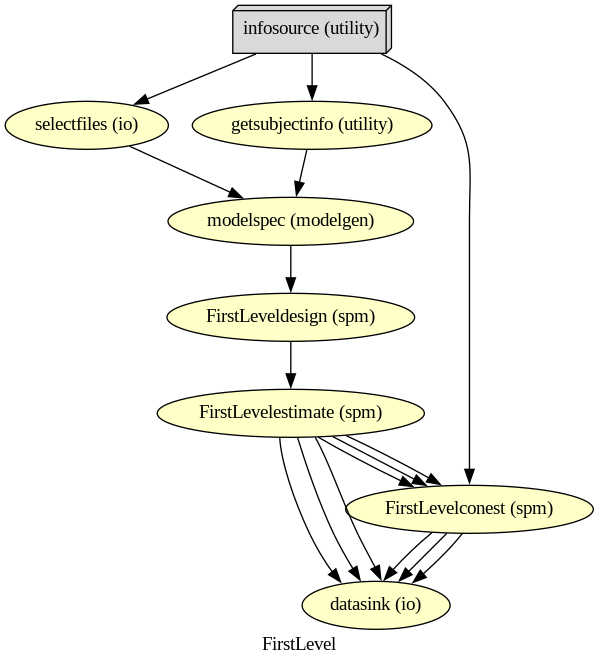

In [15]:
# Create 1st-level analysis output graph
FirstLevel.write_graph(graph2use='colored', format='png', dotfilename='colored_l1analysis.dot', simple_form=True)

# Visualize the graph
from IPython.display import Image
Image(filename=os.path.join(FirstLevel.base_dir, 'FirstLevel', 'colored_l1analysis.png'))

In [16]:
FirstLevel.write_graph(graph2use='flat', format='png', dotfilename='flat_l1analysis.dot', simple_form=True)

240712-17:48:51,802 nipype.workflow INFO:
	 Generated workflow graph: /home/matay/spmbasics/data/output/workingdir/FirstLevel/flat_l1analysis.png (graph2use=flat, simple_form=True).


'/home/matay/spmbasics/data/output/workingdir/FirstLevel/flat_l1analysis.png'

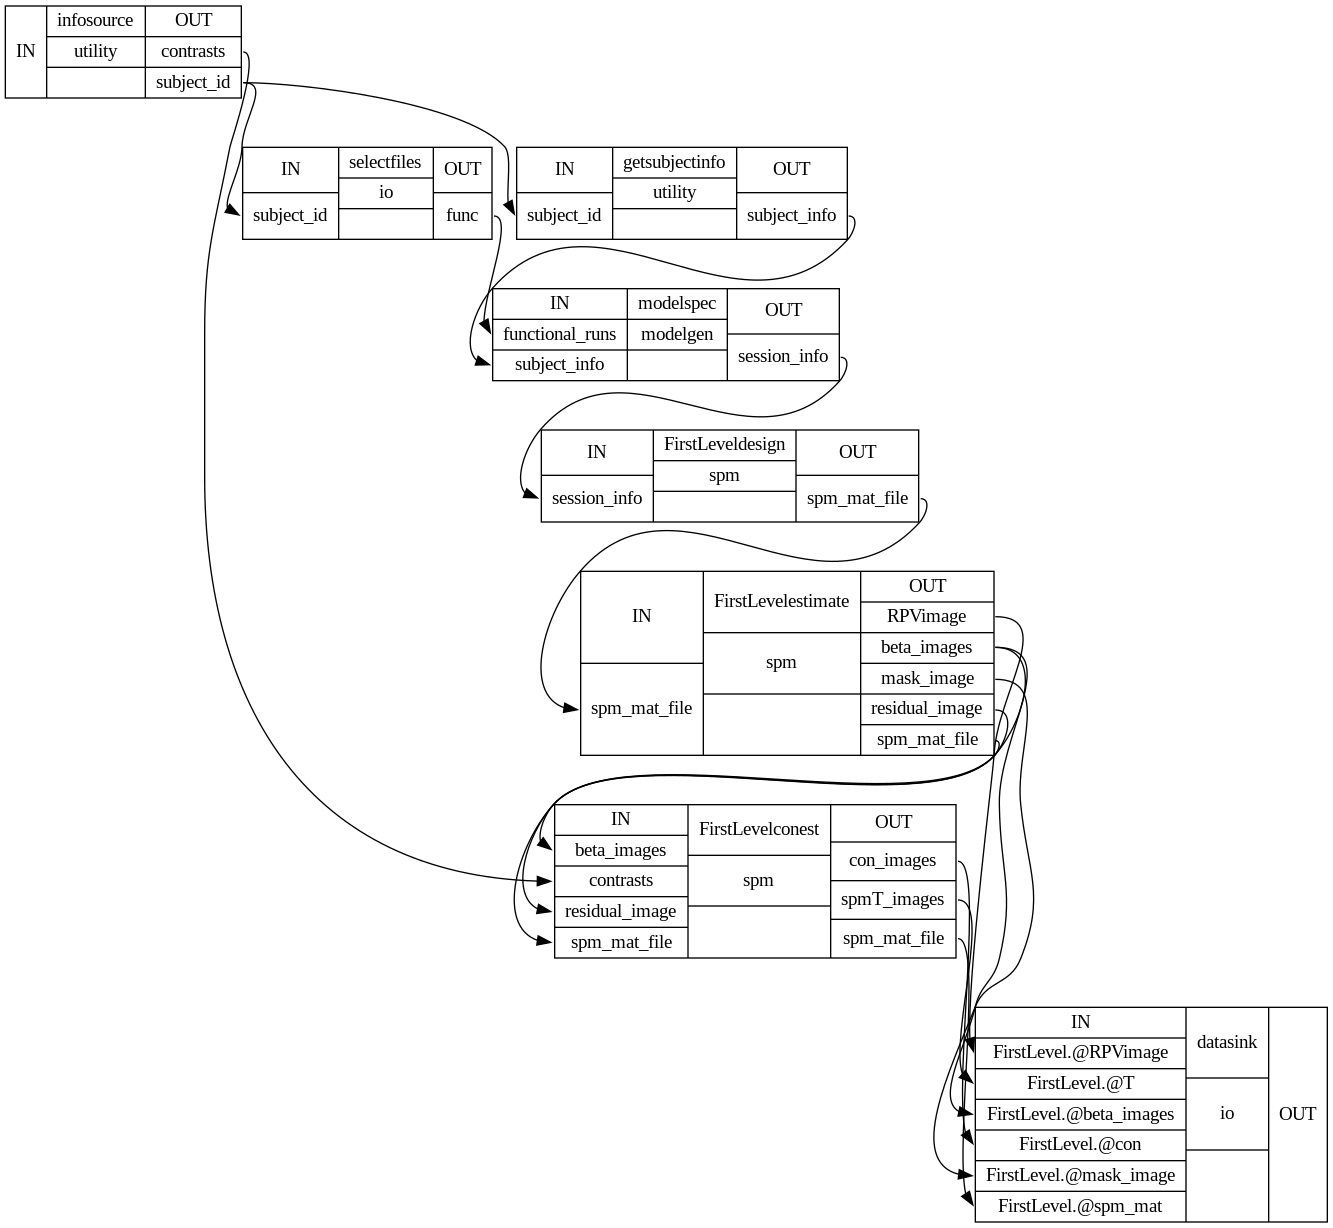

In [17]:
# Visualize the graph
from IPython.display import Image
Image(filename=os.path.join(FirstLevel.base_dir, 'FirstLevel', 'flat_l1analysis_detailed.png'))

In [18]:
FirstLevel.run('MultiProc', plugin_args={'n_procs': 4})

240712-17:48:51,817 nipype.workflow INFO:
	 Workflow FirstLevel settings: ['check', 'execution', 'logging', 'monitoring']
240712-17:48:51,822 nipype.workflow INFO:
	 Running in parallel.
240712-17:48:51,823 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 13.77/13.77, Free processors: 4/4.
240712-17:48:51,894 nipype.workflow INFO:
	 [Job 1] Cached (FirstLevel.getsubjectinfo).
240712-17:48:51,895 nipype.workflow INFO:
	 [Node] Setting-up "FirstLevel.selectfiles" in "/home/matay/spmbasics/data/output/workingdir/FirstLevel/_subject_id_01/selectfiles".
240712-17:48:51,904 nipype.workflow INFO:
	 [Node] Executing "selectfiles" <nipype.interfaces.io.SelectFiles>
240712-17:48:51,908 nipype.workflow INFO:
	 [Node] Finished "selectfiles", elapsed time 0.001136s.
240712-17:48:53,825 nipype.workflow INFO:
	 [Job 0] Completed (FirstLevel.selectfiles).
240712-17:48:53,826 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB):

stty: 'standard input': Inappropriate ioctl for device


240712-17:49:18,31 nipype.workflow INFO:
	 [Node] Finished "FirstLevelestimate", elapsed time 13.657801s.


stty: 'standard input': Inappropriate ioctl for device


240712-17:49:19,853 nipype.workflow INFO:
	 [Job 4] Completed (FirstLevel.FirstLevelestimate).
240712-17:49:19,857 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 13.77/13.77, Free processors: 4/4.
240712-17:49:19,920 nipype.workflow INFO:
	 [Node] Setting-up "FirstLevel.FirstLevelconest" in "/home/matay/spmbasics/data/output/workingdir/FirstLevel/_subject_id_01/FirstLevelconest".
240712-17:49:19,930 nipype.workflow INFO:
	 [Node] Executing "FirstLevelconest" <nipype.interfaces.spm.model.EstimateContrast>
240712-17:49:21,854 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 13.57/13.77, Free processors: 3/4.
                     Currently running:
                       * FirstLevel.FirstLevelconest


stty: 'standard input': Inappropriate ioctl for device


240712-17:49:36,255 nipype.workflow INFO:
	 [Node] Finished "FirstLevelconest", elapsed time 9.877467s.


stty: 'standard input': Inappropriate ioctl for device


240712-17:49:37,870 nipype.workflow INFO:
	 [Job 5] Completed (FirstLevel.FirstLevelconest).
240712-17:49:37,874 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 13.77/13.77, Free processors: 4/4.
240712-17:49:37,942 nipype.workflow INFO:
	 [Node] Outdated cache found for "FirstLevel.datasink".
240712-17:49:37,946 nipype.workflow INFO:
	 [Node] Setting-up "FirstLevel.datasink" in "/home/matay/spmbasics/data/output/workingdir/FirstLevel/_subject_id_01/datasink".
240712-17:49:37,949 nipype.workflow INFO:
	 [Node] Outdated cache found for "FirstLevel.datasink".
240712-17:49:37,953 nipype.workflow INFO:
	 [Node] Executing "datasink" <nipype.interfaces.io.DataSink>
240712-17:49:37,955 nipype.workflow INFO:
	 [Node] Finished "datasink", elapsed time 0.000978s.
240712-17:49:39,871 nipype.workflow INFO:
	 [Job 6] Completed (FirstLevel.datasink).
240712-17:49:39,874 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 0 jobs ready. Free memory (GB): 1